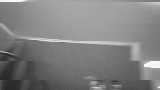

Stopped.


In [2]:
#final script
#working

from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
import cv2
from IPython.display import display, clear_output
from PIL import Image
import os

# Monkey‑patch
import pynq.lib.video.dma
pynq.lib.video.dma.AxiVDMA.mm2s_introut = None
pynq.lib.video.dma.AxiVDMA.s2mm_introut = None

# -------------------------------
# Load Haar cascade from local file
# -------------------------------
cascade_path = 'haarcascade_frontalface_default.xml'  # Update if needed
if not os.path.isfile(cascade_path):
    raise FileNotFoundError(f"Cascade file not found: {cascade_path}")
face_cascade = cv2.CascadeClassifier(cascade_path)
if face_cascade.empty():
    raise RuntimeError(f"Could not load face cascade from {cascade_path}")

# Create output directory if it doesn't exist
output_dir = '/home/xilinx/jupyter_notebooks/imgProc/faces/'
os.makedirs(output_dir, exist_ok=True)

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

vdma_cap = overlay.axi_vdma_0
vdma_proc = overlay.axi_vdma_1
accel = overlay.image_accelerator_0

# Configure accelerator
print("Configuring accelerator...")
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x00)

# Configure VDMAs
print("\nConfiguring VDMAs...")
vdma_cap.readchannel.reset()
vdma_cap.readchannel.mode = VideoMode(1920, 1080, 24)

vdma_cap.writechannel.reset()
vdma_cap.writechannel.mode = VideoMode(1920, 1080, 24)

vdma_proc.readchannel.reset()
vdma_proc.readchannel.mode = VideoMode(480, 270, 8)

print("Waiting for HDMI source...")
time.sleep(2)

# Start VDMAs
vdma_cap.readchannel.start()
vdma_cap.writechannel.start()
vdma_proc.readchannel.start()

# Start accelerator
accel.write(0x00, 0x01)
print("Accelerator started.\n")

frame_count = 0
last_save_time = time.time()
save_cooldown = 2.0  # seconds between saves to avoid flooding

try:
    while True:
        time.sleep(0.026)  #

        # Restart accelerator if done
        ctrl = accel.read(0x00)
        if ctrl & 0x02:
            frame_count += 1
            accel.write(0x00, 0x01)

        # Grab raw frame (BGR order) and processed grayscale frame
        raw_bgr = vdma_cap.readchannel._frames[0]
        raw_rgb = raw_bgr[:, :, ::-1].copy()
        vdma_cap.writechannel._frames[0][:] = raw_rgb
        proc_frame = vdma_proc.readchannel._frames[0]  # (270,480) uint8

        # --- Face detection (every 8 frames) ---
        if frame_count % 8 == 0:
            # Detect faces in the grayscale image
            faces = face_cascade.detectMultiScale(
                proc_frame,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(30, 30)
            )

            for (x, y, w, h) in faces:
                print(f"Face detected at ({x},{y}) size {w}x{h} in grayscale")

                # Scale to full resolution (1920x1080)
                x_full = x * 4
                y_full = y * 4
                w_full = w * 4
                h_full = h * 4

                # Add a 20% margin around the face
                margin_w = int(w_full * 0.0)
                margin_h = int(h_full * 0.0)

                x_start = max(0, x_full - margin_w)
                y_start = max(0, y_full - margin_h)
                x_end = min(1920, x_full + w_full + margin_w)
                y_end = min(1080, y_full + h_full + margin_h)

                # Crop using the expanded coordinates
                if x_end > x_start and y_end > y_start:
                    face_crop = raw_bgr[y_start:y_end, x_start:x_end]

                    # Save with timestamp (only if cooldown passed)
                    now = time.time()
                    if now - last_save_time > save_cooldown:
                        timestamp = time.strftime("%Y%m%d_%H%M%S")
                        filename = f"{output_dir}face_{timestamp}_{x}_{y}.jpg"
                        cv2.imwrite(filename, face_crop)
                        print(f"Saved {filename}")
                        last_save_time = now
                        
                    

        # --- Display grayscale feed at low resolution ---
        # Resize for display (e.g., 320x180) to reduce CPU load
        display_img = cv2.resize(proc_frame, (160, 90))
        img_pil = Image.fromarray(display_img)
        clear_output(wait=True)
        display(img_pil)

except KeyboardInterrupt:
    pass
finally:
    vdma_cap.readchannel.stop()
    vdma_cap.writechannel.stop()
    vdma_proc.readchannel.stop()
    print("Stopped.")

In [1]:
#with aws integration
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
import cv2
from IPython.display import display, clear_output
from PIL import Image
import os
import base64
import json
import paho.mqtt.client as mqtt
from pathlib import Path

# -------------------------------
# MQTT Configuration (from boilerplate)
# -------------------------------
MQTT_ENDPOINT = "acse20kw9idxo-ats.iot.eu-west-2.amazonaws.com"
MQTT_PORT     = 8883
NODE_ID       = "node1"

BASE_DIR    = Path("/home/xilinx/jupyter_notebooks/imgProc")
CERTS_DIR   = BASE_DIR / "certs"
CA_CERT     = CERTS_DIR / "AmazonRootCA1.pem"
CLIENT_CERT = CERTS_DIR / "node1-certificate.pem.crt"
CLIENT_KEY  = CERTS_DIR / "node1-private.pem.key"

TOPIC_FRAME    = "attendance/node1/frame"
TOPIC_DECISION = "attendance/node1/decision"
TOPIC_EXIT     = "attendance/node1/exit"

decision_received = None   # will hold the latest decision from the server

# -------------------------------
# MQTT callbacks
# -------------------------------
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("[+] Connected to AWS IoT Core")
        client.subscribe(TOPIC_DECISION)
    else:
        print(f"[-] MQTT connection failed: rc={rc}")

def on_message(client, userdata, msg):
    global decision_received
    try:
        data     = json.loads(msg.payload)
        decision = data.get("decision")
        person   = data.get("person_id", "Unknown")
        already  = data.get("already_inside", False)

        print(f"\n{'='*40}")
        if decision == "GRANT":
            if already:
                print(f"  STATUS:  ALREADY INSIDE")
                print(f"  PERSON:  {person}")
            else:
                print(f"  STATUS:  ACCESS GRANTED")
                print(f"  PERSON:  {person}")
                print(f"  DOOR:    UNLOCKED (simulated)")
        else:
            print(f"  STATUS:  ACCESS DENIED")
            print(f"  DOOR:    LOCKED (simulated)")
        print(f"{'='*40}\n")

        decision_received = decision
    except Exception as e:
        print(f"[-] Error parsing decision: {e}")

def connect_mqtt():
    """Create and start the MQTT client."""
    client = mqtt.Client(client_id="pynq-node1")
    client.tls_set(
        ca_certs=str(CA_CERT),
        certfile=str(CLIENT_CERT),
        keyfile=str(CLIENT_KEY),
    )
    client.on_connect = on_connect
    client.on_message = on_message
    print(f"[+] Connecting to {MQTT_ENDPOINT}...")
    client.connect(MQTT_ENDPOINT, MQTT_PORT, keepalive=60)
    client.loop_start()
    time.sleep(2)   # give time for the connection to establish
    return client

# -------------------------------
# Haar cascade setup
# -------------------------------
cascade_path = 'haarcascade_frontalface_default.xml'
if not os.path.isfile(cascade_path):
    raise FileNotFoundError(f"Cascade file not found: {cascade_path}")
face_cascade = cv2.CascadeClassifier(cascade_path)
if face_cascade.empty():
    raise RuntimeError(f"Could not load face cascade from {cascade_path}")

# Create output directory for local copies
output_dir = '/home/xilinx/jupyter_notebooks/imgProc/faces/'
os.makedirs(output_dir, exist_ok=True)

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

vdma_cap = overlay.axi_vdma_0
vdma_proc = overlay.axi_vdma_1
accel = overlay.image_accelerator_0

# Configure accelerator
print("Configuring accelerator...")
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x00)

# Configure VDMAs
print("\nConfiguring VDMAs...")
vdma_cap.readchannel.reset()
vdma_cap.readchannel.mode = VideoMode(1920, 1080, 24)

vdma_cap.writechannel.reset()
vdma_cap.writechannel.mode = VideoMode(1920, 1080, 24)

vdma_proc.readchannel.reset()
vdma_proc.readchannel.mode = VideoMode(480, 270, 8)

print("Waiting for HDMI source...")
time.sleep(2)

# Start VDMAs
vdma_cap.readchannel.start()
vdma_cap.writechannel.start()
vdma_proc.readchannel.start()

# Start accelerator
accel.write(0x00, 0x01)
print("Accelerator started.\n")

# -------------------------------
# Connect to AWS IoT via MQTT
# -------------------------------
mqtt_client = connect_mqtt()

frame_count = 0
last_send_time = time.time()
send_cooldown = 2.0   # seconds between sends to avoid flooding

try:
    while True:
        time.sleep(0.026) #fps

        # Restart accelerator if done
        ctrl = accel.read(0x00)
        if ctrl & 0x02:
            frame_count += 1
            accel.write(0x00, 0x01)

        # Grab raw frame (BGR order) and processed grayscale frame
        raw_bgr = vdma_cap.readchannel._frames[0]
        raw_rgb = raw_bgr[:, :, ::-1].copy()
        vdma_cap.writechannel._frames[0][:] = raw_rgb
        proc_frame = vdma_proc.readchannel._frames[0]  # (270,480) uint8

        # --- Face detection (every 8 frames) ---
        if frame_count % 8 == 0:
            faces = face_cascade.detectMultiScale(
                proc_frame,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(30, 30)
            )

            for (x, y, w, h) in faces:
                print(f"Face detected at ({x},{y}) size {w}x{h} in grayscale")

                # Scale to full resolution (1920x1080)
                x_full = x * 4
                y_full = y * 4
                w_full = w * 4
                h_full = h * 4

                # Add a margin
                margin_w = int(w_full * 0.1)
                margin_h = int(h_full * 0.1)

                x_start = max(0, x_full - margin_w)
                y_start = max(0, y_full - margin_h)
                x_end = min(1920, x_full + w_full + margin_w)
                y_end = min(1080, y_full + h_full + margin_h)

                if x_end > x_start and y_end > y_start:
                    face_crop = raw_bgr[y_start:y_end, x_start:x_end]

                    # Cooldown check
                    now = time.time()
                    if now - last_send_time > send_cooldown:
                        # --- Encode image and send via MQTT ---
                        # Convert BGR (OpenCV) to JPEG in memory
                        _, jpeg_buffer = cv2.imencode('.jpg', face_crop, [cv2.IMWRITE_JPEG_QUALITY, 85])
                        img_bytes = jpeg_buffer.tobytes()
                        img_b64 = base64.b64encode(img_bytes).decode('utf-8')

                        payload = json.dumps({
                            "image": img_b64,
                            "node_id": NODE_ID
                        })

                        # Publish to the frame topic
                        mqtt_client.publish(TOPIC_FRAME, payload)
                        print(f"[+] Sent face image ({len(img_bytes)} bytes) to AWS")

                        # save locally as well
                        timestamp = time.strftime("%Y%m%d_%H%M%S")
                        filename = f"{output_dir}face_{timestamp}_{x}_{y}.jpg"
                        cv2.imwrite(filename, face_crop)
                        print(f"   Also saved locally: {filename}")

                        last_send_time = now

        # --- Display grayscale feed at low resolution ---
        display_img = cv2.resize(proc_frame, (160, 90))
        img_pil = Image.fromarray(display_img)
        clear_output(wait=True)
        display(img_pil)

except KeyboardInterrupt:
    pass
finally:
    # Stop VDMAs
    vdma_cap.readchannel.stop()
    vdma_cap.writechannel.stop()
    vdma_proc.readchannel.stop()
    # Disconnect MQTT
    mqtt_client.loop_stop()
    mqtt_client.disconnect()
    print("Stopped.")

ModuleNotFoundError: No module named 'paho'